# From spectrum to staffing: the business of predictable demand

The first two notebooks built the tools and proved them on a famous
series. This one spends them the way an operations team would.

Every service business runs on a demand series with rhythms in it:
calls into a contact center, traffic on a network, arrivals at an
emergency room, orders at a warehouse. Three questions come up in
every planning meeting about such a series, and this notebook answers
each with the toolkit:

1. **Which rhythms does demand actually have, and how strong are
   they?** (The spectrum's job.)
2. **What should next Tuesday 8am look like?** (A baseline, and a
   fair fight between two ways of building one.)
3. **When should someone get paged?** (An anomaly alarm built on the
   baseline, plus what capacity planning does with the whole picture.)

Our stand-in for all of those businesses is real hourly demand data:
vehicle counts on Interstate 94 between Minneapolis and St Paul, from
the UCI Machine Learning Repository. A road is a service with fixed
capacity, rush hours, quiet Sundays, holidays, and weather disasters,
which is to say it behaves exactly like your call center.

The data's flaws first, because real telemetry is never pristine. The raw file has duplicate rows where several
weather records share one hour, a months-long sensor outage in
2014-2015, scattered missing hours, and a holiday flag stamped only
on midnight rows. `data/build_dataset.py` documents every repair: we
keep January 2016 through September 2018, where no gap exceeds nine
hours, place the series on a strict hourly grid, interpolate the 4.2%
of hours that are missing, and spread each holiday flag across its
day. Every cleaning decision is in that script, not in a footnote you
cannot audit.

24096 hours, 2016-01-01 to 2018-09-30, mean 3313 vehicles/hour, holidays flagged: 28 days


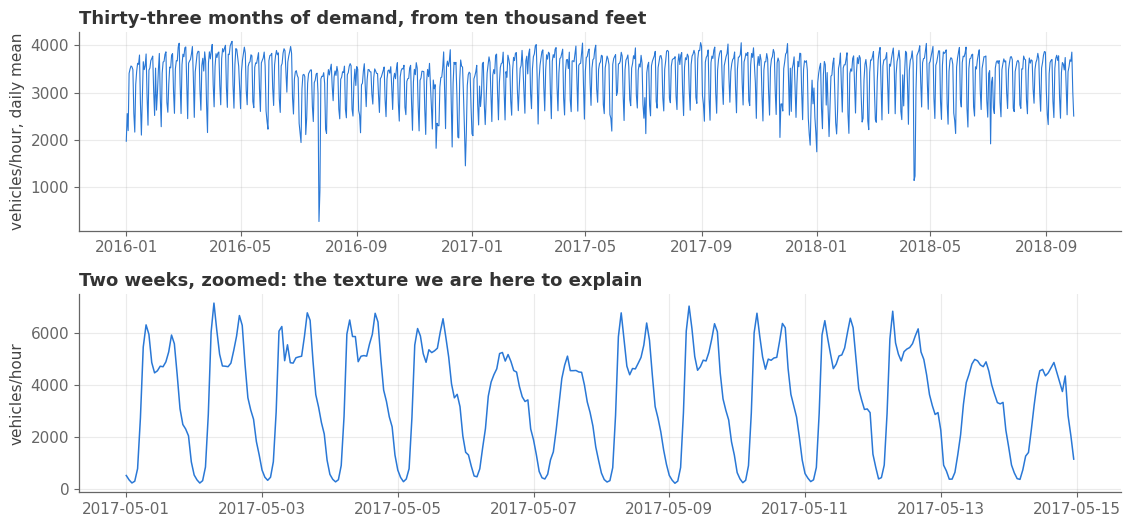

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from numpy.fft import rfft, rfftfreq

# Some BLAS builds raise spurious matmul warnings inside lstsq.
warnings.filterwarnings('ignore', message='.*encountered in matmul.*')

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, GRAY, INK = '#fab219', '#d03b3b', '#8a8f98', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

df = (pd.read_csv('../data/metro_traffic.csv', parse_dates=['date_time'])
      .set_index('date_time'))
v = df['traffic_volume']

fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.4))
daily_mean = v.resample('D').mean()
axes[0].plot(daily_mean.index, daily_mean, color=BLUE, lw=0.8)
axes[0].set_ylabel('vehicles/hour, daily mean')
axes[0].set_title('Thirty-three months of demand, from ten thousand feet')
week = v.loc['2017-05-01':'2017-05-14']
axes[1].plot(week.index, week, color=BLUE, lw=1.1)
axes[1].set_ylabel('vehicles/hour')
axes[1].set_title('Two weeks, zoomed: the texture we are here to explain')
fig.tight_layout()

print(f"{len(v)} hours, {v.index.min():%Y-%m-%d} to {v.index.max():%Y-%m-%d}, "
      f"mean {v.mean():.0f} vehicles/hour, holidays flagged: "
      f"{int(df.is_holiday.sum() / 24)} days")

The zoom already telegraphs the answers: each weekday is a
two-humped animal (morning and evening rush), weekends are single
gentle mounds, and the whole shape repeats week after week. But
"look, it repeats" is not a measurement. The spectrum makes it one.

## The spectrum of a working week

Notebook 02's discipline demands one question before any transform:
is there a trend to remove? Here, no. The overview panel is flat,
and the yearly means printed below wobble by a few percent with no
direction to the drift, so subtracting the overall mean is all the
detrending this series needs. That check takes one line, and skipping the
question, rather than answering it, is the mistake.

With `d=1/24` the frequency axis reads in cycles per day, the
natural unit here. We plot amplitude on a log scale because the
peaks span two orders of magnitude, and we tabulate everything worth
naming.

yearly mean vehicles/hour: {2016: 3247, 2017: 3374, 2018: 3319}


,cycles per day,"period, hours","amplitude, veh/h"
0,1.0000,24.0,2245.0
1,2.0000,12.0,728.0
2,3.0000,8.0,589.0
3,0.1424,168.5,365.0
4,0.8576,28.0,323.0
5,5.0000,4.8,316.0
6,1.8576,12.9,270.0
7,0.7141,33.6,260.0


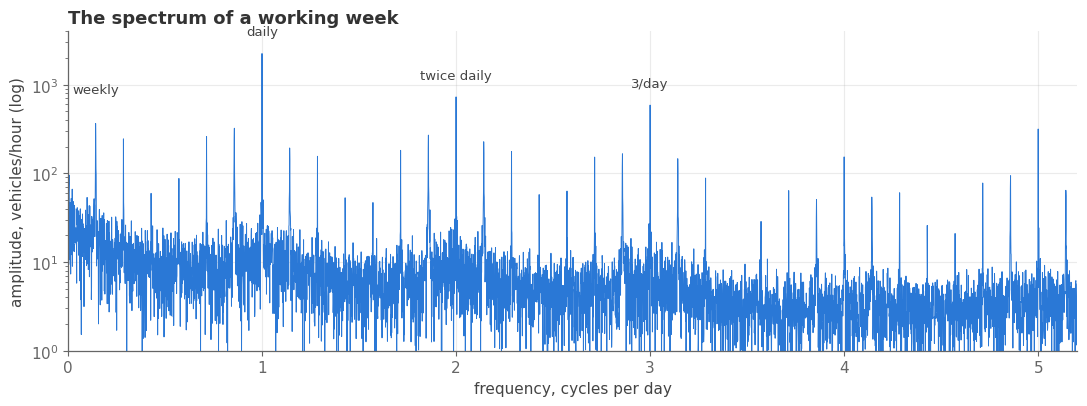

In [2]:
print("yearly mean vehicles/hour:",
      {y: round(v.loc[str(y)].mean()) for y in (2016, 2017, 2018)})

n = len(v)
freqs = rfftfreq(n, d=1 / 24)               # cycles per day
amp = np.abs(rfft((v - v.mean()).values)) * 2 / n

fig, ax = plt.subplots(figsize=(11.0, 4.2))
ax.semilogy(freqs, amp, color=BLUE, lw=0.7)
ax.set_xlim(0, 5.2)
ax.set_ylim(1, 4000)
ax.set_xlabel('frequency, cycles per day')
ax.set_ylabel('amplitude, vehicles/hour (log)')
ax.set_title('The spectrum of a working week')
for f_, label, dy in ((1, 'daily', 1.6), (2, 'twice daily', 1.6),
                      (3, '3/day', 1.6), (1 / 7, 'weekly', 2.2)):
    k = np.argmin(np.abs(freqs - f_))
    k = k - 2 + np.argmax(amp[k - 2:k + 3])
    ax.annotate(label, xy=(freqs[k], amp[k]), xytext=(freqs[k], amp[k] * dy),
                ha='center', fontsize=9.5, color='#444444')
fig.tight_layout()
fig.savefig('../pic/traffic_spectrum.png', dpi=150, bbox_inches='tight',
            facecolor='white')

top = np.argsort(amp)[::-1][:8]
table = pd.DataFrame({'cycles per day': freqs[top].round(4),
                      'period, hours': (24 / freqs[top]).round(1),
                      'amplitude, veh/h': amp[top].round(0)})
table

Read the table the way notebook 02 taught, because a naive reading
gets at least two rows wrong.

**The daily cycle rules.** The 24-hour line is by far the tallest,
around 2,200 vehicles per hour of amplitude: day versus night is the
biggest fact about this road.

**The 12-hour and 8-hour lines are not separate cycles.** Nothing on
this road independently repeats every twelve hours. These are the
harmonics of the daily *shape*: a day whose profile is two rush-hour
humps rather than one smooth sine needs, by notebook 02's chord
logic, a fundamental plus strong harmonics to draw it. The
harmonics are the rush hours, spelled in Fourier.

**The weekly line and its entourage.** The peak at 0.14 cycles per
day (168.5 hours on our grid, the point nearest the 168-hour week)
is the working week itself. And if you look closely at the table you
will find peaks at frequencies like 0.857 and 1.857 cycles per day,
one seventh away from the daily line and its harmonic. Those are
**sidebands**: the daily cycle's strength is modulated by the week
(strong Monday to Friday, weak Saturday and Sunday), and a modulated
cycle splits its spectral line into copies shifted by the modulating
frequency. Radio engineers build AM broadcasting on exactly this
effect; here it is the spectrum's way of writing "weekends are
different". Sidebands come as a family at multiples of one seventh
away, which also explains the table's 0.714 row: the daily line
shifted by two sevenths, the next copy out.

An analogy is not evidence, so manufacture the effect and watch:

In [3]:
hours_syn = np.arange(24 * 7 * 100)          # a hundred synthetic weeks
carrier = np.cos(2 * np.pi * hours_syn / 24)
modulated = (1 + 0.5 * np.cos(2 * np.pi * hours_syn / 168)) * carrier

f_syn = rfftfreq(len(hours_syn), d=1 / 24)
a_syn = np.abs(rfft(modulated)) * 2 / len(hours_syn)
for k in sorted(np.argsort(a_syn)[::-1][:3]):
    print(f"line at {f_syn[k]:.4f} cycles/day, amplitude {a_syn[k]:.2f}")

line at 0.8571 cycles/day, amplitude 0.25
line at 1.0000 cycles/day, amplitude 1.00
line at 1.1429 cycles/day, amplitude 0.25


A pure daily wave whose strength swells and fades over the week
produces exactly three lines: the carrier at 1 cycle per day and two
copies at 1 minus 1/7 and 1 plus 1/7, the very frequencies sitting
in the real table. The AM story is now a second witness, this
series' standard of proof.

So the spectrum's verdict, in one sentence: everything about this
series is a function of the hour within the week, 24-hour and
168-hour structure plus their harmonics, and nothing else with
comparable energy. Time-domain plots should confirm it at a
glance.

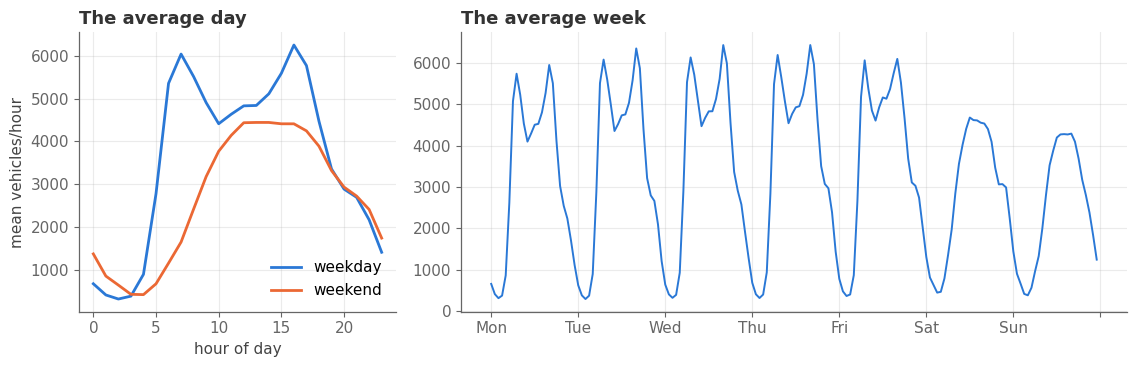

In [4]:
hour_of_week = v.index.dayofweek * 24 + v.index.hour

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8),
                         gridspec_kw={'width_ratios': [1, 2.1]})
weekday = v[v.index.dayofweek < 5].groupby(
    v[v.index.dayofweek < 5].index.hour).mean()
weekend = v[v.index.dayofweek >= 5].groupby(
    v[v.index.dayofweek >= 5].index.hour).mean()
axes[0].plot(weekday.index, weekday, color=BLUE, lw=2, label='weekday')
axes[0].plot(weekend.index, weekend, color=ORANGE, lw=2, label='weekend')
axes[0].set_xlabel('hour of day')
axes[0].set_ylabel('mean vehicles/hour')
axes[0].set_title('The average day')
axes[0].legend()

prof_all = v.groupby(hour_of_week).mean()
axes[1].plot(prof_all.index, prof_all, color=BLUE, lw=1.4)
axes[1].set_xticks(range(0, 169, 24))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun', ''])
axes[1].set_title('The average week')
fig.tight_layout()

There they are in the flesh: the two weekday humps the harmonics
were drawing (a sharp 7am spike and a taller, broader 4pm one), and
the weekend's single lazy mound that powers the sidebands. Spectrum
and time domain tell one story, which is exactly the two-witness
standard this series holds itself to.

## From diagnosis to baseline: two candidates, one fair fight

Planning needs a number per future hour: the **baseline**, what
demand looks like when nothing special is happening. The spectrum
just told us the baseline is a function of hour-of-week, and there
are two natural ways to build one:

- **Climatology**: the lookup table we already drew. For each of the
  168 hour-of-week slots (Monday midnight is slot 0, Sunday 11pm is
  slot 167), the historical mean. Zero mathematics, 168 parameters.
- **Harmonic regression**: regress demand on sine and cosine pairs
  at the daily and weekly frequencies and their first K harmonics,
  exactly the components the spectrum found. Smooth by
  construction, and with K = 6 it needs only 25 parameters.

Two pieces of vocabulary so the code below holds no surprises.
`np.linalg.lstsq` finds the coefficients that make the weighted sum
of sines and cosines track the data with the smallest total squared
error; that is all "regression" means here. We grade with MAE, the
average absolute miss in vehicles per hour, and with R squared, the
share of the held-out variance a baseline explains, where 1.0 is
perfect. (One quirk worth a comment: at K = 10 the seventh weekly
harmonic *is* the daily fundamental, so two columns duplicate; least
squares absorbs the overlap harmlessly.)

Which is better is an empirical question, so we treat it like one,
with the discipline used everywhere in this series: fit both on 2016
and 2017, evaluate both on the first nine months of 2018 (January
through September, all the holdout there is), data neither has
seen.

In [5]:
train, test = v.loc[:'2017-12-31'], v.loc['2018-01-01':]
how_tr = train.index.dayofweek * 24 + train.index.hour
how_te = test.index.dayofweek * 24 + test.index.hour

# candidate 1: climatology
prof = train.groupby(how_tr).mean()
pred_clim = pd.Series(how_te.map(prof), index=test.index)

# candidate 2: harmonic regression on daily + weekly frequencies
t0 = v.index[0]
def harmonic_design(index, K):
    t = (index - t0).total_seconds().values / 3600.0
    cols = [np.ones(len(t))]
    for period in (24.0, 168.0):
        for k in range(1, K + 1):
            cols.append(np.sin(2 * np.pi * k * t / period))
            cols.append(np.cos(2 * np.pi * k * t / period))
    return np.column_stack(cols)

rows = []
for K in (3, 6, 10):
    beta, *_ = np.linalg.lstsq(harmonic_design(train.index, K),
                               train.values, rcond=None)
    pred_h = harmonic_design(test.index, K) @ beta
    mae = np.abs(test.values - pred_h).mean()
    r2 = 1 - ((test.values - pred_h) ** 2).sum() /         ((test.values - test.values.mean()) ** 2).sum()
    rows.append((f'harmonic, K={K}', 4 * K + 1, mae, r2))

mae_c = (test - pred_clim).abs().mean()
r2_c = 1 - ((test - pred_clim) ** 2).sum() /     ((test - test.mean()) ** 2).sum()
rows.append(('climatology', 168, mae_c, r2_c))

scores = pd.DataFrame(rows, columns=['baseline', 'parameters',
                                     'MAE on 2018, veh/h', 'R2 on 2018'])
scores.round(3)

,baseline,parameters,"MAE on 2018, veh/h",R2 on 2018
0,"harmonic, K=3",13,626.495,0.813
1,"harmonic, K=6",25,522.809,0.866
2,"harmonic, K=10",41,495.888,0.879
3,climatology,168,266.504,0.944


The lookup table wins, and not by a hair: a mean absolute error of
267 vehicles per hour (8% of mean demand) against roughly 500 for
the best harmonic fit, explaining 94% of the held-out variance
against 88%. It is worth being precise about why, because the lesson
generalizes.

Truncated Fourier baselines are smooth by construction, and this
road's reality is not smooth: the morning rush is a cliff (a few
hundred vehicles before dawn, six thousand by seven), and drawing
cliffs takes many harmonics. Meanwhile the climatology has about 104
training observations per slot, plenty to nail all 168 numbers
without any smoothness assumption. Harmonic regression earns its keep in the opposite
regime: short records, gappy data, non-integer periods, or when you
need a defensible extrapolation formula rather than a table.

Which leaves the spectrum with a clarified role, and this is the
notebook's method lesson: **the spectrum was the diagnosis, not the
model.** It told us *which* structure exists (hour-of-week, nothing
else) and therefore which baselines were candidates at all. Choosing
among candidates is then ordinary backtesting. Skip the diagnosis
and you risk fitting cycles that are not there; skip the backtest
and you risk shipping elegant mathematics that loses to a lookup
table.

## The baseline as an alarm

A baseline that predicts normal is, read backwards, a detector of
abnormal. For each 2018 hour, compute how many training-era standard
deviations demand sits from its slot's baseline (a **z-score** per
hour-of-week slot, since a quiet 3am and a roaring 5pm have very
different natural variability), and flag hours beyond three.

In [6]:
resid_tr = train - pd.Series(how_tr.map(prof), index=train.index)
sigma = resid_tr.groupby(how_tr).std()

z = (test - pred_clim) / pd.Series(how_te.map(sigma), index=test.index)
flags = z[z.abs() > 3]

by_day = (pd.DataFrame({'z': flags})
          .assign(day=flags.index.date)
          .groupby('day').agg(hours_flagged=('z', 'size'),
                              worst_z=('z', lambda s: s[s.abs().idxmax()])))
by_day = by_day.sort_values('hours_flagged', ascending=False)

print(f"hours flagged in 2018: {len(flags)} of {len(test)} "
      f"({len(flags) / len(test):.1%})")
print("\nthe worst days:")
display(by_day.head(7))

info = df.loc[test.index]
flagged_days = by_day.head(7).index
for d in list(flagged_days):
    day_rows = info[info.index.date == d]
    month_temp = info[info.index.month == d.month]['temp_c'].mean()
    print(f"{d}  holiday={bool(day_rows.is_holiday.iloc[0])!s:5}  "
          f"day temp {day_rows.temp_c.mean():5.1f} C  "
          f"(that month's mean {month_temp:5.1f} C)")

hours flagged in 2018: 127 of 6552 (1.9%)

the worst days:


,hours_flagged,worst_z
day,,
2018-01-01,19,9.594332
2018-07-04,15,-10.073559
2018-04-15,14,-3.890128
2018-04-14,13,-5.211978
2018-01-22,10,-7.669244
2018-01-11,9,-4.013407
2018-05-28,7,-3.569244


2018-01-01  holiday=True   day temp -22.2 C  (that month's mean  -8.9 C)
2018-07-04  holiday=True   day temp  24.3 C  (that month's mean  22.5 C)
2018-04-15  holiday=False  day temp  -3.6 C  (that month's mean   2.5 C)
2018-04-14  holiday=False  day temp  -2.6 C  (that month's mean   2.5 C)
2018-01-22  holiday=False  day temp  -0.7 C  (that month's mean  -8.9 C)
2018-01-11  holiday=False  day temp  -9.3 C  (that month's mean  -8.9 C)
2018-05-28  holiday=True   day temp  28.0 C  (that month's mean  18.8 C)


The alarm's hit list explains itself with data already in the file,
and even the sign column talks: New Year's Day flags *positive*
(small-hours party traffic towering over a normal 2am baseline)
while the summer holidays flag missing daytime demand. Same calendar
cause, opposite signatures.
New Year's Day, Independence Day, and Memorial Day carry the holiday
flag: the calendar speaking, not an incident. The rest are winter
days, and one of them stands out: a mid-April weekend that dipped
below freezing (the temperature column shows minus two to minus four
against a monthly mean of plus 2.5) while traffic collapsed by more
than half. Sub-freezing cold plus a demand collapse in April is the
fingerprint of a late-season snowstorm, and the alarm caught both
days of it. Here is what that weekend looked like against the
baseline.

Saturday April 14: traffic 60% below a normal Saturday


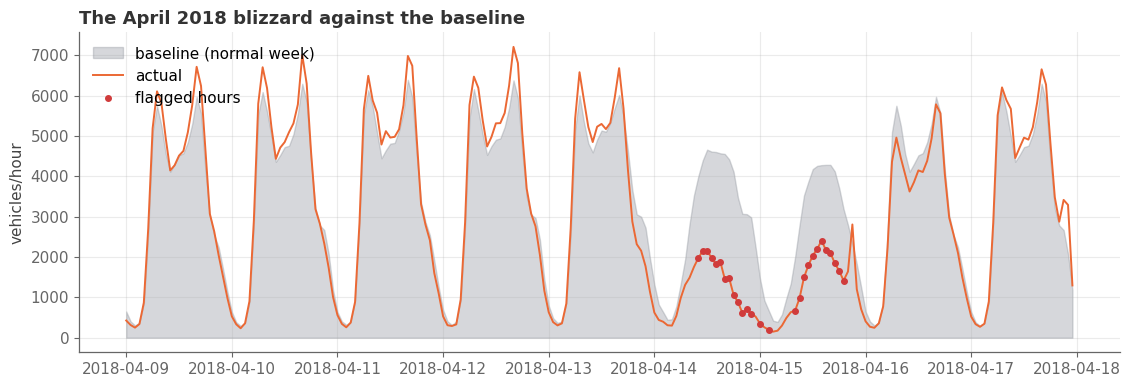

In [7]:
window = slice('2018-04-09', '2018-04-17')
actual = test.loc[window]
base_w = pred_clim.loc[window]

fig, ax = plt.subplots(figsize=(11.5, 4.0))
ax.fill_between(base_w.index, base_w, color=GRAY, alpha=0.35,
                label='baseline (normal week)')
ax.plot(actual.index, actual, color=ORANGE, lw=1.4, label='actual')
flagged_w = flags.loc[window]
ax.plot(flagged_w.index, actual.loc[flagged_w.index], 'o', color=RED,
        ms=4, label='flagged hours')
ax.set_ylabel('vehicles/hour')
ax.set_title('The April 2018 blizzard against the baseline')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig('../pic/traffic_anomalies.png', dpi=150, bbox_inches='tight',
            facecolor='white')

drop = 1 - actual.loc['2018-04-14'].sum() / base_w.loc['2018-04-14'].sum()
print(f"Saturday April 14: traffic {drop:.0%} below a normal Saturday")

The storm cut Saturday's demand by 60%, the alarm fired through the
weekend, and, just as important, it stayed quiet through the
ordinary weeks around it: a 1.9% flag rate across the nine test
months, concentrated in exactly the days a Minnesotan could name
from memory. For a contact center, replace blizzard with outage and
holiday with product launch; the mathematics does not care.

Two operational notes worth stating. First, the alarm knows the
difference between "quiet because 3am" and "quiet because something
is wrong at 8am", which is precisely what the per-slot z-scores buy
and what a single global threshold never can. Second, holidays are
*predictably* anomalous: the right production fix is a calendar
feature in the baseline, at which point the alarm stops spending its
voice on the calendar and saves it for weather and incidents.

## What this means for capacity

The same baseline settles planning arguments, because the seasonal
profile *is* the capacity question. Demand at the evening peak is
not "a bit above average"; it is structurally almost double the
mean, every working day. Size anything (lanes, agents, servers) to
average demand and you have designed a system that fails on
schedule, ten times a week.

In [8]:
peak_hour = prof.idxmax()
print(f"busiest baseline slot: hour {peak_hour % 24} on day "
      f"{['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][peak_hour // 24]}, "
      f"{prof.max():.0f} veh/h vs overall mean {v.mean():.0f} "
      f"({prof.max() / v.mean():.2f}x)")

top_decile = v.sort_values(ascending=False).head(len(v) // 10)
print(f"the busiest 10% of hours carry {top_decile.sum() / v.sum():.1%} "
      f"of all traffic")

rows = []
for name, cap in [('mean demand', v.mean()),
                  ('80th pct of baseline', np.percentile(prof, 80)),
                  ('95th pct of baseline', np.percentile(prof, 95)),
                  ('baseline max', prof.max())]:
    over = test[test > cap]
    rows.append((name, int(cap), len(over),
                 (test - cap).clip(lower=0).sum() / test.sum()))
capacity = pd.DataFrame(rows, columns=[
    'capacity sized to', 'veh/h', 'hours over capacity in 2018',
    'share of demand unserved'])
capacity['share of demand unserved'] = (
    capacity['share of demand unserved'].map('{:.2%}'.format))
capacity

busiest baseline slot: hour 16 on day Wed, 6395 veh/h vs overall mean 3313 (1.93x)
the busiest 10% of hours carry 18.8% of all traffic


,capacity sized to,veh/h,hours over capacity in 2018,share of demand unserved
0,mean demand,3312,3441,26.13%
1,80th pct of baseline,5104,1391,4.63%
2,95th pct of baseline,5971,485,0.94%
3,baseline max,6395,224,0.25%


The table is the negotiation every operations lead recognizes,
with real numbers attached. Capacity at the mean fails for
thousands of hours in nine months. Sizing to the baseline's 95th
percentile cuts unserved demand below one percent, and the marginal
capacity above that buys only a thin sliver of ordinary peak hours.
(The storm weekend never enters this table at all: a blizzard is a
demand *collapse*, a revenue problem rather than a congestion
problem, which is exactly why it lives in the alarm section
instead.) Where the line belongs is a business judgment about the
cost of a lost vehicle-hour versus an idle lane; what the analysis
contributes is that the judgment is now about two numbers on a
table instead of adjectives in a meeting.

## Honest limits

1. **We interpolated 4.2% of hours** and said so; on a gappier
   record, interpolation would start inventing rhythm, and
   gap-tolerant methods (Lomb-Scargle) would be the right tool.
2. **Holidays are not periodic.** No frequency-domain method will
   ever predict July 4; that is calendar knowledge and belongs in
   the baseline as a feature. Our alarm flagging holidays is the
   symptom, and it is fixable, not fundamental.
3. **One sensor, one direction, three years.** The rhythms are
   stable here, but demand patterns drift (a pandemic rewrote every
   commuting spectrum on Earth), so production baselines get
   re-estimated on a schedule, with the drift monitoring lesson
   from my Markov series applying unchanged.
4. **Weather is exogenous.** The alarm detects storms; predicting
   their impact needs forecast features, a different (and
   supervised) modeling problem.

## Takeaways

1. The spectrum is the diagnosis: it named the structures (daily,
   weekly, harmonics as rush hours, sidebands as weekends) and
   ruled out everything else worth modeling.
2. The baseline choice is an experiment, not an aesthetic: the
   168-slot lookup table beat truncated Fourier regression on held-
   out data, 267 against roughly 500 vehicles per hour of MAE, and
   the reasons why generalize to your data.
3. One artifact, three jobs: the same hour-of-week baseline prices
   normal (planning), detects abnormal (a 1.9% alarm that found the
   snowstorms and the holidays), and frames capacity (mean-sizing
   fails on schedule; the 95th percentile is where the argument
   starts).
4. Everything rests on the discipline of the first two notebooks:
   check for trend before transforming, verify with two witnesses, and test
   on time the model never saw.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*